<a href="{{ colab_base_laboratorios }}/Laboratorio_08_clasificacionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 8: Clasificacion Logística 

Si deseamos clasificar algún tipo de imagen, resultado en campos medicos, astrofisicos se pueden aplicar algoritmos de clasificación. En particular en esta sesión se estudia los principios basicos de  regresión logística para aplicarla a los  modelos de clasificación. 

Supongamos que queremos clasificar un sistema que tiene dos tipos posibles (los llamaremos los tipos 0 y 1) basado en dos características (correspondiente a dos variables X1 y X2) :



In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification,make_circles
import numpy as np

Text(0, 0.5, 'X_2')

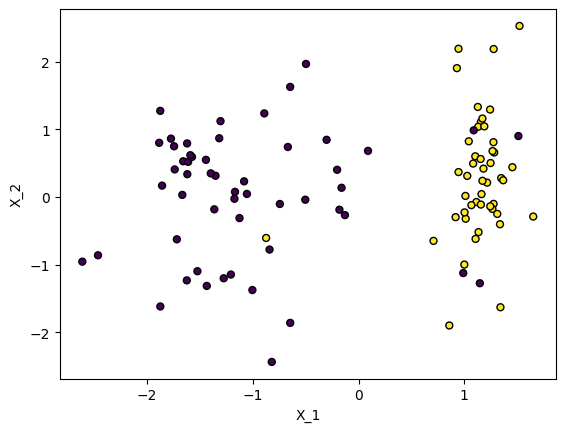

In [6]:
#Vamos a crear los datos de dos tipos introduciendo un porcentaje de
#valores con "ruido" (flip_y). Pruebe a cambiar el valor
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.xlabel("X_1")
plt.ylabel("X_2")

En este caso cada color representa los objetos tipos 0 y tipo 1. Para aplicar un algoritmo de clasificación relacionaremos el valor $h_{\theta}(X^{i}=x)$ con la probabilidad de obtener un valor de y dado un x parametrizado por $\theta$, $P(y=1|X=x;\theta)$, asi : 

 $h_{\theta}(X^{i}=x) = P(y=1|X^{i};\theta) $ 

 Tenemos que:  $P(y=1|x;\theta)+P(y=0|x;\theta) = 1$

Si tenemos muestra equiprobables, podemos definir lo siguiente  para P :

- $P<0.5$ se obtienen los objetos tipo 0 
- $P \geq 0.5$ se obtienen los objetos tipo 1

Podemos establecer un clasificador de los  sistemas basado en las probabilidades a partir de un clasificador logístico:


\begin{equation}
f(z)=\frac{1}{(1+e^{-z})}
\end{equation}
Cuya derivada es :

\begin{equation}
f'(z)=f(z)(1-f(z))
\end{equation}



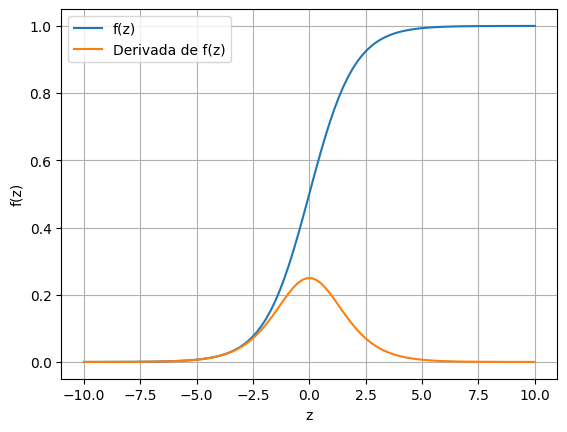

In [7]:
f = lambda x: 1/(1+np.exp(-x))
fp = lambda x: f(x)*(1-f(x))
z=np.linspace(-10, 10, 100)

plt.figure()
plt.plot(z,f(z), label="f(z)")
plt.plot(z,fp(z), label="Derivada de f(z)")
plt.ylabel("f(z)")
plt.xlabel("z")
plt.grid()
plt.legend()

- Para valores de $z< 0.0$ la regresión logistica clasica objetos tipo 0, siendo $f(z)<0.5$
- Para valores de $z\geq 0.0$ la regresión logística clasica objetos tipo 1 siendo $f(z) \geq  0.5$

¿Cual es la probabilidad de que dado un hyperplano, los valores de un hyperlado sean objetos tipo 0 o tipo 1?

Aplicando la regresión logistica, a las regresiones multivariadas estudiadas en la sesiones anteriores, tenemos que el argumento $z=\Theta^{T} X$, así:


\begin{equation}
h_{\theta}(X)=\frac{1}{(1+e^{-\Theta^T X})}
\end{equation}


- Se cumple que para los valores del hyperplano  $\Theta^T X\geq 0.0$, $y = 1$ 
- Se cumple que para  $\Theta^T X < 0.0$ , $y = 0$ 


Las condiciones anteriores permiten definir fronteras de desicion entre los datos a clasificar. Para los datos dados arriba, se puede establecer el siguiente clasificador.


$h_\theta(x) = g(\theta_0+\theta_1 x_1+\theta_2 x_2 ) $. 

Una clasificación del dataset nos sugiere que la frontera para este dataset es: 

$\theta_0+\theta_1 x_1+\theta_2 x_2 \geq 0.0$

Si por algun metodo encontramos que los parametros $\Theta$ entonces podemos definir la frontera de clasifiación. Como ejemplo supongamos que encontramos los siguientes parametros $\Theta=[3.0, -20, 1.0]$

Ecnontrar la ecuacion de la recta y mejorar la parametrizacion

$3-20x1+x2=0$

$x_2= 20 x_1 - 3$

In [8]:
x1 = np.linspace(0, 0.29, 100)
x2 = 20*x1-3

Text(0, 0.5, 'X_2')

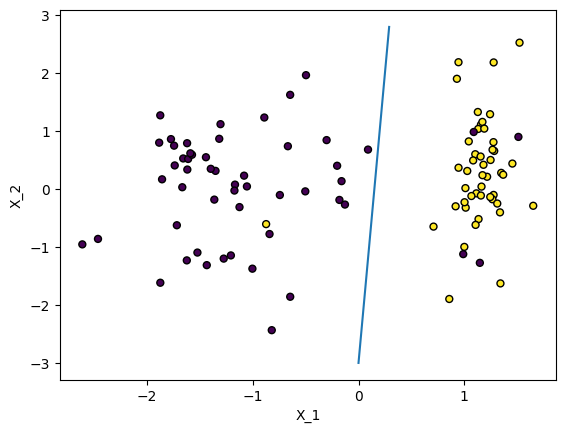

In [9]:
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.plot(x1, x2)
plt.xlabel("X_1")
plt.ylabel("X_2")

TODO: revisar signo de $\Theta^T X$ en la exponencial

Fronteras no lineal también puede ser consideradas, para ello se puede definir  $\Theta^T X$ como funcion de un polinomio, por ejemplo 

$\Theta^T X =  \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2$

\begin{equation}
h_\theta(X) =  \frac{1}{1+e^{-(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2)}}
\end{equation}

La frontera de desición en este caso esta determinada por:

$\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2 \geq 0$ 
para obtener un clasificador con valores de y = 1.

Para este mismo caso, supongamos que tenmos la siguiente distribución de datos, ¿Cuál es el mejor elección de parámetros $\Theta$ que permite clasificar los datos siguientes:







(np.float64(-1.12244940477901),
 np.float64(1.1839643638442499),
 np.float64(-1.2696420440360447),
 np.float64(1.185918477713659))

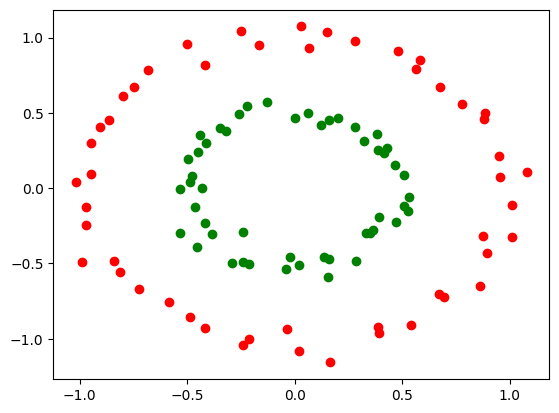

In [10]:
X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1
f, ax = plt.subplots()
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")
plt.axis("tight")

Analizando el conjunto de datos, se puede observar que la frontera es la de una circunferencia con centro en (0, 0) y radio de 0.7 aproxidamente,  asi nuestra elección de parámetros para el polinomio ejemplicado en la celda anterior ($\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1^4 \geq 0$ ) es: 


$\Theta^T = [-0.7,0, 0, 1,1 ] $ 

Reemplando tenemos que:

$-0.7+x_1^2+x_2^2 \geq 0$

$x_1^2+x_2^2 \geq 0.7$

Text(0, 0.5, 'X_2')

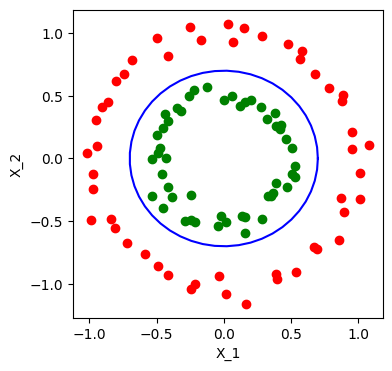

In [11]:
#Por motivos graficos transformemos la ecuación anterior parametrizada
#por theta 

alpha = np.linspace(0, 2*np.pi)
x1=0.7*np.cos(alpha)
x2=0.7*np.sin(alpha)

X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1

f, ax = plt.subplots(figsize=(4,4))
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")

plt.plot(x1, x2,"b-")
plt.axis("tight")
plt.xlabel("X_1")
plt.ylabel("X_2")

De forma general, ¿Cómo pueden ser elegidos los valores de $\Theta$?.



Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{-\Theta ^T (X)}}
\end{equation}



Para ello, podemos definir la función de coste como :


\begin{equation}
J = \left \{ 
  \begin{array}{ c l }
    -\log h(x) & \quad \textrm{if } y = 1 \\
    -\log (1-h(x))  & \quad \textrm{if } y = 0 \\
  \end{array}
\right.
\end{equation}



Resumida en la siguiente expresión:


$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

Esta función de coste permite establecer el mejor clasificadose para la regresión logistica de acuerdo a la teoría de probabilidad. Se garantiza que cuando $P(y=1|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=0|x,\theta)$, analogamente, se cumple que cuando $P(y=0|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=1|x,\theta)$. 
La metrica empleada para la regresión lineal no es recomedada en este caso, dado que la funcion de coste puede presentar múltiples minimos que dificultan la minimizacion  a través de algunas de las técnicas empleadas. Una justificación adicional para la métrica  es dada mas adelante segun la teoria de la probabilidad.

Se deja como tarea motrar que:

\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[-y^{(i)}+h_\theta X^{(i)}] X_j^{(i)}
\end{equation}

Para la demostración, muestre que:
- $f'(z)= f(z)(1-f(z))$ usando que $f(z)=\frac{1}{1+e^{-z}} $
- $\frac{\partial h_{\theta}}{\partial \theta_j } = h_{\theta}(X^{(i)})(1-h_{\theta}(X^{(i)}))X_j^{(i)}$


La derivada permite aplicar el gradiente descendente para minimizar nuestra función de coste asi,  nuestro algoritmo de minimizacion permite encontrar los valores de $\theta$ despues de un conjunto determinado de itereaciones.

$\theta_j: \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$


Otros metodos de minizacion podrian ser aplicados, tales como:


[Gradiente conjugado ](https://es.wikipedia.org/wiki/M%C3%A9todo_del_gradiente_conjugado#:~:text=En%20matem%C3%A1tica%2C%20el%20m%C3%A9todo%20del,son%20sim%C3%A9tricas%20y%20definidas%20positivas.&text=Varios%20m%C3%A9todos%20del%20gradiente%20conjugado,de%20las%20ecuaciones%20no%20lineales)

[BFGS](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm)


[L-BGFS](https://en.wikipedia.org/wiki/Limited-memory_BFGS)

[Newton-Rhapson](https://en.wikipedia.org/wiki/Newton%27s_method)


# Interpretación probabilística


¿Qué tan adeacuado es la elección de $J(\theta)$  para el modelo de regresion logistica?



\begin{equation}
P(y=1|x;\theta)= h_{\theta}(X^{(i)})
\end{equation}

\begin{equation}
P(y=0|x;\theta)= 1-h_{\theta}(X^{(i)}) 
\end{equation}



\begin{equation}
P(y|x;\theta)=[h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

Asumiendo que los datos de entrenamiento son independientes:

$\cal{L}(\theta)=p(\vec{y}|x, \theta)$

\begin{equation}
\cal{L}(\theta)=\prod_{i=1}^{m} [h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

tomando el logaritmo:


\begin{equation}
\log \cal{L}(\theta)= \sum_{i=1}^{m} y \log h_{\theta}(X^{(i)}) + (1-y)\log (1-h_{\theta}(X^{(i)}))
\end{equation}

Los datos a considerar son los mas probables es decir que para encontrar los valores de $\theta$ que nos garantizan la maxima probabilidad es necesario maximar la función anterior. Despues de realizar los calculos se puede mostrar la ecuación dada para el gradiente de la función de coste.



En conclusión se cumple que:

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{\Theta ^T X}}
\end{equation}



- Función de coste
$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[-y^{(i)}+h_\theta X^{(i)}] X_j^{(i)}
\end{equation}





# Regularización 


## Regresion Logistica
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{i=1}^{n} \theta_i^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[-y^{(i)}+h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{\alpha}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)} 
\end{equation}



### Normal equation 
\begin{equation}
\theta=(X^TX\lambda L)^{-1} X^T y
\end{equation}

\begin{equation}
\lambda=\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\end{equation}

Las dimensiones de $[\lambda]=(\mathrm{n+1}) \times (\mathrm{n+1})$



## Regresion Logistica
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{j=1}^{n} \theta_j^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{\alpha}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)} 
\end{equation}



# Tomar el [iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) desde sklearn:

```
from sklearn import datasets

iris = datasets.load_iris()
```
- Realizar la clasifición de las tres clases  a traves de una regresión logística  y realizar multiclasicación, para ello considere lo siguiente:

Si en un dataset existen más de 2 clases, $y={0, 1, 2, 3, ...}$ se debe construir una multiclasificación, una contra todos, la estrategia sugerida es la siguiente.

Sea A, B, C las tres clases. Para estos valores definir:

1. Definir la clase A como la clase 0 y todas las otras B, C como la clase 1
2. Encontrar el valor $h_\theta(X) = P(y=A|x;\theta)$
3. Definir la clase B como la clase 0 y todas las otras A, C como la clase 1
4. Encontrar el valor $h_\theta(X) = P(y=B|x;\theta)$
5. Definir la clase C como la clase 0 y todas las otras A, B como la clase 1
6. Encontrar el valor $h_\theta(X) = P(y=C|x;\theta)$


Estrategia de solución. 

1. Para tener una vision general de los datos analiza lo que contiene la clave DESCR del dataset
```
print(iris.DESCR)
```

In [24]:
# 1.
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
print(iris.DESCR)
print("="*30)
iris

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

2. Construye un dataframe: 
- los datos se pueden encontrar con la clave "data".
- los nombres de las caracteristicas con la clave: "names_features"
- La clave target nos permite indentificar el tipo de datos.

In [32]:
# 2.
#iris.feature_names
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
print(df["target"].value_counts()) # 0-> setosa, 1-> versicolor, 2-> virginica
df.head()

target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


3. Cambia el nombre de las columnas del dataframe, empleando intrucción como:
```
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ] 
cols = [col.replace(")" ,"") for col in columns_name ] 
```

In [34]:
#3
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ] 
cols = [col.replace(")" ,"") for col in columns_name ]
df.columns = cols
df.head()

,Sepallength_cm,Sepalwidth_cm,Petallength_cm,Petalwidth_cm,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


4. Analizar el dataframe, numeros de datos, cantidad de null, descripción del dataframe.

In [35]:
print(df.describe())
print("="*30)
print(df.info())
print("="*30)
print(df.shape)

       Sepallength_cm  Sepalwidth_cm  Petallength_cm  Petalwidth_cm  \
count      150.000000     150.000000      150.000000     150.000000   
mean         5.843333       3.057333        3.758000       1.199333   
std          0.828066       0.435866        1.765298       0.762238   
min          4.300000       2.000000        1.000000       0.100000   
25%          5.100000       2.800000        1.600000       0.300000   
50%          5.800000       3.000000        4.350000       1.300000   
75%          6.400000       3.300000        5.100000       1.800000   
max          7.900000       4.400000        6.900000       2.500000   

           Target  
count  150.000000  
mean     1.000000  
std      0.819232  
min      0.000000  
25%      0.000000  
50%      1.000000  
75%      2.000000  
max      2.000000  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----

La data está completa, aunque hay relativamente pocos datos (150).

5. Aplica estadística básica y construye graficas para entender el dataset. Encuentra la matriz de correlacion

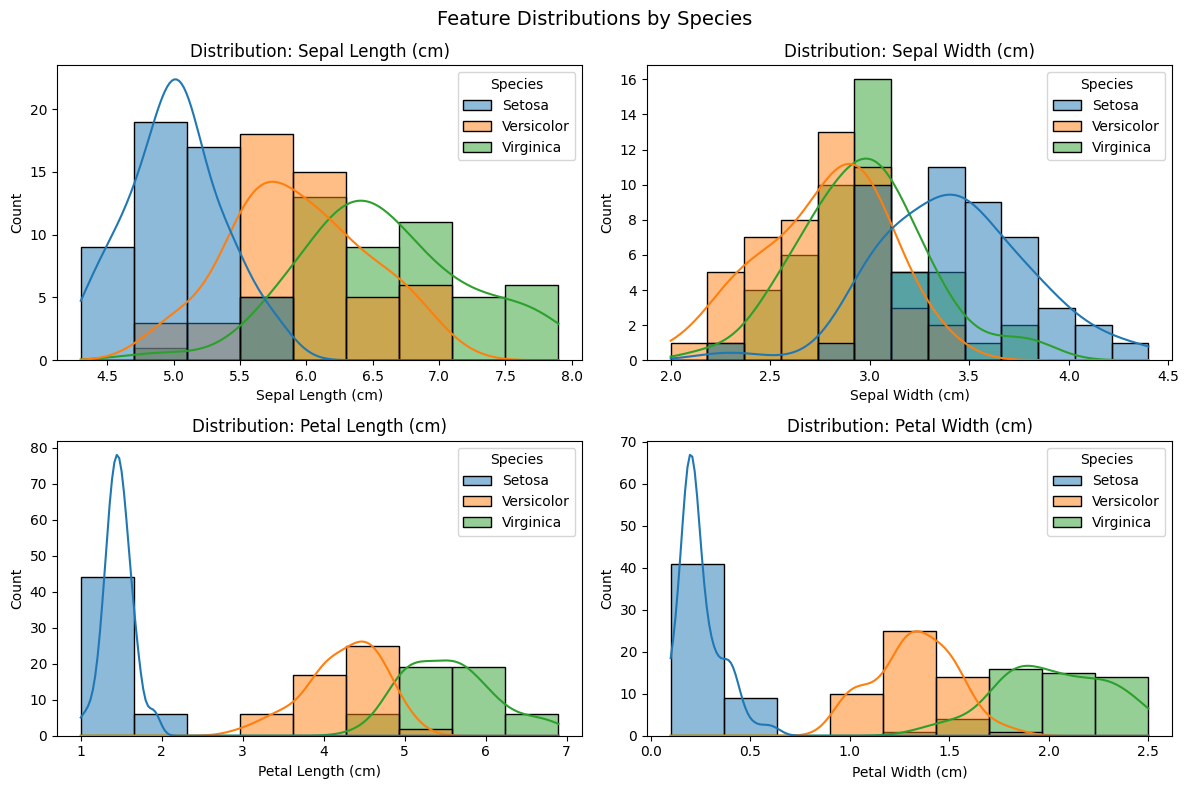

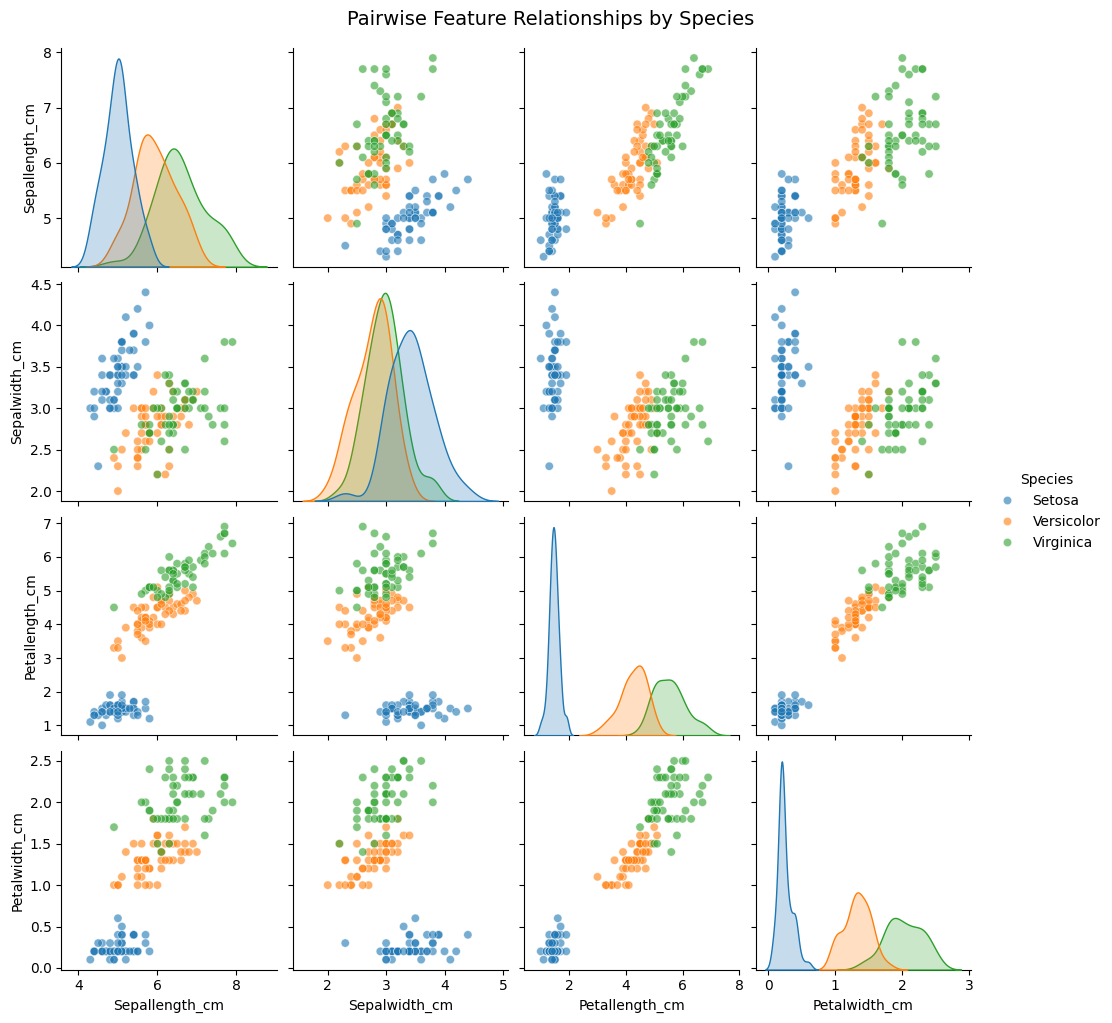

/tmp/ipykernel_68354/2909325197.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_68354/2909325197.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_68354/2909325197.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_68354/2909325197.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


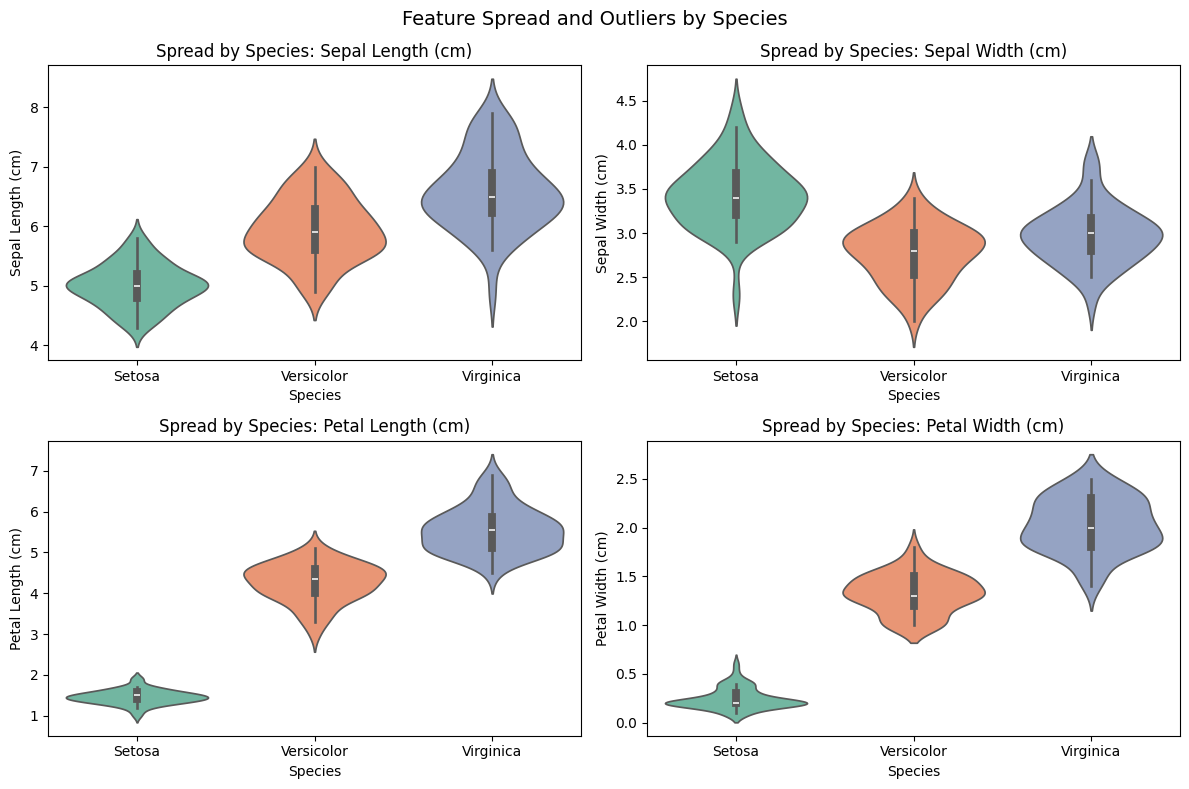

In [36]:
import seaborn as sns

# Map integer target to species names for readable legends
target_names = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}
df_plot = df.copy()
df_plot["Species"] = df["Target"].map(target_names)

feature_cols = ["Sepallength_cm", "Sepalwidth_cm", "Petallength_cm", "Petalwidth_cm"]
feature_labels = ["Sepal Length (cm)", "Sepal Width (cm)", "Petal Length (cm)", "Petal Width (cm)"]

# ── 1. Histograms with KDE overlay, one per feature ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    sns.histplot(
        data=df_plot, x=col, hue="Species",
        kde=True,       # density curve makes shape comparison easier than raw counts
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_xlabel(label)
    axes[i].set_title(f"Distribution: {label}")

plt.suptitle("Feature Distributions by Species", fontsize=14)
plt.tight_layout()
plt.show()

# ── 2. Pair plot: all pairwise scatters + diagonal KDE in one matrix ──────────
pair_grid = sns.pairplot(
    df_plot,
    vars=feature_cols,
    hue="Species",
    diag_kind="kde",    # diagonal shows per-class density instead of histogram
    plot_kws={"alpha": 0.6}
)
pair_grid.figure.suptitle("Pairwise Feature Relationships by Species", y=1.02, fontsize=14)
plt.show()

# ── 3. Violin plots: median, IQR, and outliers per class ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    sns.violinplot(
        data=df_plot, x="Species", y=col,
        palette="Set2",
        inner="box",    # shows quartile box inside the violin
        ax=axes[i]
    )
    axes[i].set_ylabel(label)
    axes[i].set_title(f"Spread by Species: {label}")

plt.suptitle("Feature Spread and Outliers by Species", fontsize=14)
plt.tight_layout()
plt.show()

Histogramas y diagrama de pares (pairplot)

Los histogramas con KDE revelan que las features de pétalo (Petallength_cm, Petalwidth_cm) presentan distribuciones claramente separadas entre las tres especies, mientras que las features de sépalo muestran un solapamiento considerable. El pairplot confirma esta observación: en los scatter plots que cruzan variables de pétalo, Setosa se agrupa de forma compacta y alejada de las otras dos clases, lo que sugiere separabilidad casi lineal. Versicolor y Virginica comparten regiones de valor en las features de sépalo, anticipando que la frontera de decisión entre estas dos clases será más difícil de aprender para el clasificador.

Violin plots

Los violin plots permiten comparar simultáneamente la posición central, la dispersión y la forma de la distribución por clase. Para Petallength_cm y Petalwidth_cm, los violines de las tres especies ocupan rangos de altura claramente distintos con mínimo solapamiento: esto indica alto poder discriminante y fronteras de decisión bien definidas. Para Sepallength_cm y Sepalwidth_cm, los violines se ubican a alturas similares y se solapan significativamente, evidenciando bajo poder discriminante individual. La clase Setosa muestra violines más angostos en las features de pétalo, lo que indica menor varianza intraclase y mayor homogeneidad en esas mediciones. En conjunto, los violin plots confirman que el clasificador logístico dependerá principalmente de las features de pétalo para separar las tres especies.

Este texto fue generado despues de 4 turnos de discusion y análisis de los gráficos con Claude

6. Encontrar la matrix de correlacion, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

Text(0.5, 1.0, 'Feature Correlation Matrix')

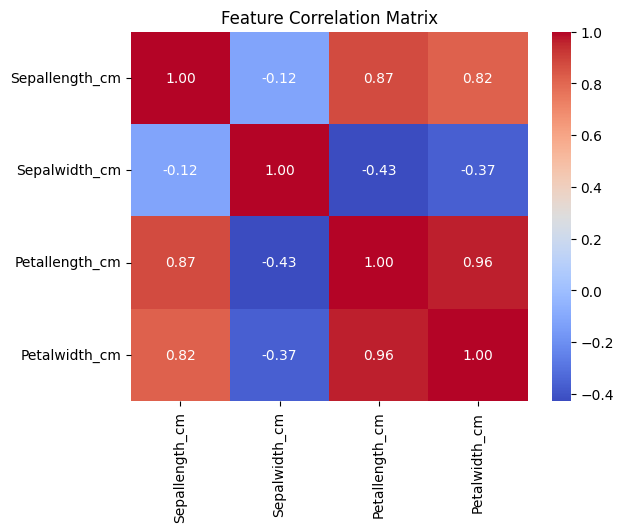

In [39]:
sns.heatmap(df[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
    strat_train_set = df.loc[train_index]
    strat_test_set  = df.loc[test_index]

print(f"Train: {len(strat_train_set)} muestras | Test: {len(strat_test_set)} muestras")
print()

# Verify class proportions are preserved after the split
print("Proporciones en el dataset completo:")
print(df["Target"].value_counts(normalize=True).sort_index().round(4))
print()
print("Proporciones en el set de entrenamiento:")
print(strat_train_set["Target"].value_counts(normalize=True).sort_index().round(4))

7. Separar los datos en datos de entramiento y test, prueba la siguiente instruccion:
```
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]
```
¿Cómo se estan seprando los datos?

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Binary target: 1 = Setosa (original Target==0), 0 = Not-Setosa
# Using (Target == 0) is cleaner than mapping each class manually — same result, less code
X_train = strat_train_set[["Petallength_cm"]].values
y_train = (strat_train_set["Target"] == 0).astype(int).values

X_test = strat_test_set[["Petallength_cm"]].values
y_test  = (strat_test_set["Target"] == 0).astype(int).values

print("Distribución de clases en y_train:")
print(f"  Not-Setosa (0): {(y_train == 0).sum()} | Setosa (1): {(y_train == 1).sum()}")
print()

# Train
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Evaluate
y_pred = log_reg.predict(X_test)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not-Setosa", "Setosa"]))

Distribución de clases en y_train:
  Not-Setosa (0): 80 | Setosa (1): 40

Accuracy en test: 1.0000

              precision    recall  f1-score   support

  Not-Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



De acuerdo con la documentación: "cross-validation method that creates randomized training and testing sets while preserving the exact percentage of samples for each target class".

En otras palabras, elimina el potencial riesgo de tener sesgos debido a la aleatoriedad, forzando que las muestras de los splits sean representativos segun cierto "estrato" o criterio.

8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa, emplea la libreria sklearn.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Binary target: 1 = Setosa (original Target==0), 0 = Not-Setosa
# Using (Target == 0) is cleaner than mapping each class manually — same result, less code
X_train = strat_train_set[["Petallength_cm"]].values
y_train = (strat_train_set["Target"] == 0).astype(int).values

X_test = strat_test_set[["Petallength_cm"]].values
y_test  = (strat_test_set["Target"] == 0).astype(int).values

print("Distribución de clases en y_train:")
print(f"  Not-Setosa (0): {(y_train == 0).sum()} | Setosa (1): {(y_train == 1).sum()}")
print()

# Train
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Evaluate
y_pred = log_reg.predict(X_test)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not-Setosa", "Setosa"]))

Distribución de clases en y_train:
  Not-Setosa (0): 80 | Setosa (1): 40

Accuracy en test: 1.0000

              precision    recall  f1-score   support

  Not-Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



9. Determine  la frontera de clasificación: 
```
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)#Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

decision_boundary = X_new[prob[:, 0] >= 0.5][0]
decision_boundary
```

In [ ]:
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)#Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

decision_boundary = X_new[prob[:, 0] >= 0.5][0] # De acuerdo con la margen de clasificacion del modelo de regresion logistica
decision_boundary

array([2.75275275])

10. Encontrar una gráfica de la regresión logística  con los valores de probabilidad

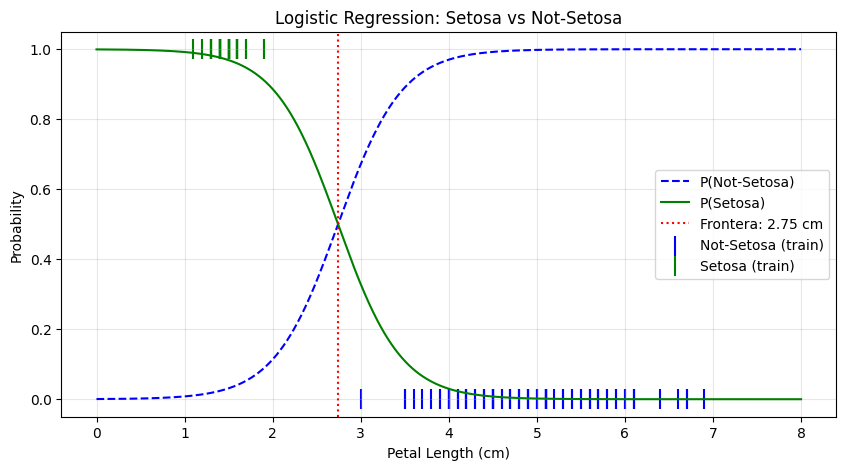

Decision boundary: 2.7467 cm


In [46]:
X_new = np.linspace(0, 8, 1000).reshape(-1, 1)
prob = log_reg.predict_proba(X_new)
decision_boundary = X_new[prob[:, 0] >= 0.5][0]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(X_new, prob[:, 0], "b--", label="P(Not-Setosa)")
ax.plot(X_new, prob[:, 1], "g-",  label="P(Setosa)")
ax.axvline(decision_boundary, color="red", linestyle=":",
           label=f"Frontera: {decision_boundary[0]:.2f} cm")

ax.scatter(X_train[y_train == 0], np.zeros((y_train == 0).sum()),
           color="blue", marker="|", s=200, label="Not-Setosa (train)")
ax.scatter(X_train[y_train == 1], np.ones((y_train == 1).sum()),
           color="green", marker="|", s=200, label="Setosa (train)")

ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Probability")
ax.set_title("Logistic Regression: Setosa vs Not-Setosa")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Decision boundary: {decision_boundary[0]:.4f} cm")

11. Construye el multiclasificador. Puede emplear los metodos dentro de logistic regresión.

In [48]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["Sepallength_cm", "Sepalwidth_cm", "Petallength_cm", "Petalwidth_cm"]

X_train_multi = strat_train_set[feature_cols].values
y_train_multi  = strat_train_set["Target"].values
X_test_multi   = strat_test_set[feature_cols].values
y_test_multi   = strat_test_set["Target"].values

# fit_transform on train only — fitting on test would leak test statistics into the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled  = scaler.transform(X_test_multi)

# multi_class='ovr' was removed in sklearn 1.5 — OvR is the default behavior
log_reg_multi = LogisticRegression(max_iter=200, random_state=42)
log_reg_multi.fit(X_train_scaled, y_train_multi)

y_pred_multi = log_reg_multi.predict(X_test_scaled)
print(f"Accuracy multiclasificador: {accuracy_score(y_test_multi, y_pred_multi):.4f}\n")
print(classification_report(y_test_multi, y_pred_multi,
                             target_names=["Setosa", "Versicolor", "Virginica"]))

Accuracy multiclasificador: 0.9333

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



12. Dado X = [4.9,5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica? 

Ayudas para mejorar las metricas: 

- Normalizar cada columna respecto a su media y desviacion estandar

```
(x-mean(x))/std(x)
```
- Determinar los datos outlier 

- Construir curvas de aprendizaje

In [49]:
# Order matches feature_cols: sepal_len, sepal_wid, petal_len, petal_wid
X_sample = np.array([[4.9, 5.0, 1.8, 0.3]])
X_sample_scaled = scaler.transform(X_sample)

probabilities   = log_reg_multi.predict_proba(X_sample_scaled)[0]
predicted_class = log_reg_multi.predict(X_sample_scaled)[0]
species_names   = ["Setosa", "Versicolor", "Virginica"]

print("Probabilidades de clasificación para X = [4.9, 5.0, 1.8, 0.3]:")
for name, p in zip(species_names, probabilities):
    print(f"  {name}: {p:.4f}  ({p * 100:.1f}%)")
print(f"\nClasificación predicha: {species_names[predicted_class]}")

Probabilidades de clasificación para X = [4.9, 5.0, 1.8, 0.3]:
  Setosa: 0.9998  (100.0%)
  Versicolor: 0.0002  (0.0%)
  Virginica: 0.0000  (0.0%)

Clasificación predicha: Setosa


# [SOFTMAX REGRESION](https://es.wikipedia.org/wiki/Funci%C3%B3n_SoftMax)


La elección anterior es conocida com softmax regresión, que permite definir un conjunto de probabilidades asociadas a un conjunto de clases. Al definir el maximo valor de la probabilidad dado un conjunto de inputs se tiene el objeto que predice el modelo, una forma de hacer una implementación rapida es mostrada a continuación.

[Referencias]  [Hand on Machine learning](https://github.com/ageron/handson-ml/blob/master/04_training_linear_models.ipynb)


# Reto, no es obligatorio.

### Clasificación de pulsar.

Para el siguiente  dataset descrito en el este enlace [pulsar](https://archive.ics.uci.edu/ml/datasets/HTRU2)  , construir un clasificador logístico, para ello, deberá primera entender las caracteristicas del problema y seguidamente estudiar el comportamiento de la clasificacion realizada.


1. Dividir los datos en train and test
2. Entrenar el algoritmo.
3. Analizar las curvas de aprendizaje.
4. Realizar Predicciones
5. Aplicar regularización.


Referencias

[1] http://cs229.stanford.edu/syllabus.html

[2] https://www.coursera.org/learn/machine-learning. Week 3.

[3] https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py


[4]https://scikit-learn.org/stable/datasets/toy_dataset.html